<a href="https://colab.research.google.com/github/Huyen-005/THDeepLearning/blob/main/Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

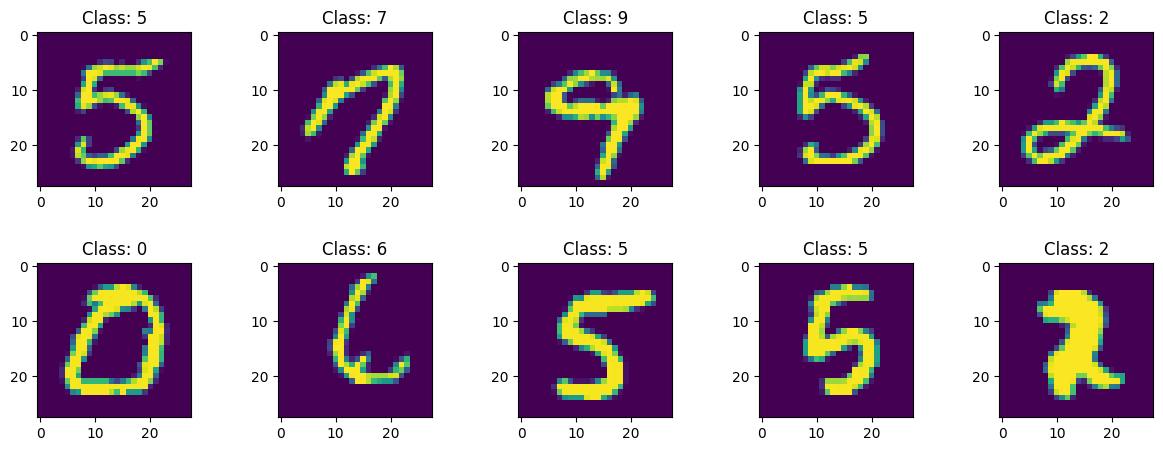

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.8461 - loss: 0.5787 - val_accuracy: 0.9370 - val_loss: 0.2113
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.9546 - loss: 0.1474 - val_accuracy: 0.9620 - val_loss: 0.1261
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9716 - loss: 0.0968 - val_accuracy: 0.9695 - val_loss: 0.0978
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9773 - loss: 0.0750 - val_accuracy: 0.9695 - val_loss: 0.0972
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.9808 - loss: 0.0598 - val_accuracy: 0.9755 - val_loss: 0.0753
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.9839 - loss: 0.0510 - val_accuracy: 0.9765 - val_loss: 0.0713
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.9854 - loss: 0.0438 - val_accuracy: 0.9795 - val_loss: 0.0725
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9882 - loss: 0.

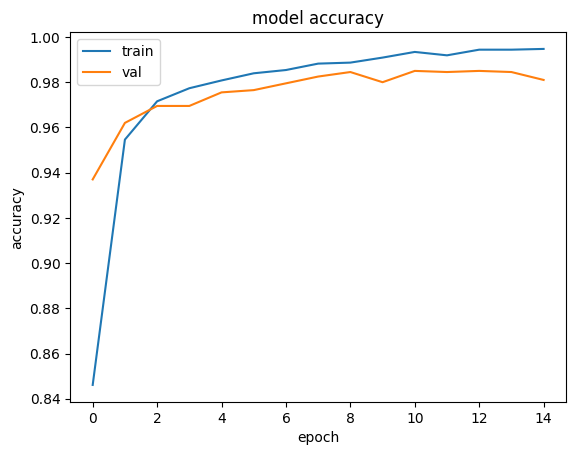

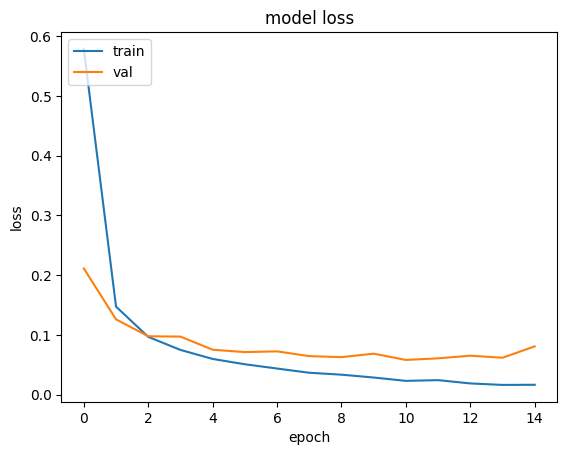

313/313 - 3s - 9ms/step - accuracy: 0.9830 - loss: 0.0656
Test loss: 0.06562260538339615
Test accuracy: 0.9829983115196228
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[5.5735629e-05 6.0115795e-05 9.9988401e-01 9.5055644e-11 2.5577627e-19
  1.1908214e-14 6.7312918e-08 1.6104755e-17 2.0170506e-10 1.5598830e-19]]
Dự đoán: 2 Thực tế: 2


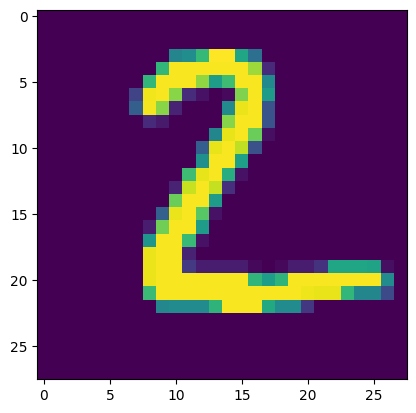

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Dự đoán mới: 1 Thực tế: 1


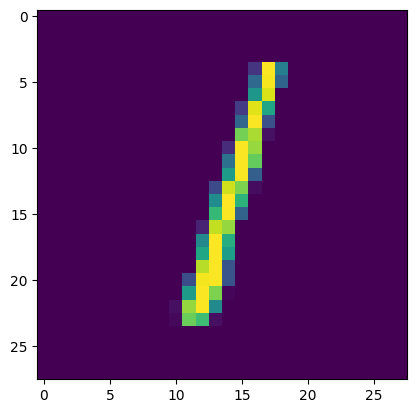

In [ ]:
# 2.1. Nạp thư viện
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# 2.2. Đọc dữ liệu MNIST
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa dữ liệu
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

# Reshape dữ liệu cho CNN
X_train = X_train.to_numpy().reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.to_numpy().reshape(X_test.shape[0], 28, 28, 1)

# 2.3. Trực quan hóa 10 ảnh đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

# 2.4. Chuyển giá trị nhãn thành one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# 2.5. Xây dựng mô hình CNN
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 2.6. Huấn luyện mô hình CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

# 2.7. Đánh giá mô hình CNN (Đồ thị accuracy và loss)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 2.8. Đánh giá mô hình trên tập test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# 2.9. Dự báo nhãn cho ảnh sử dụng CNN
predict = model.predict(X_test[:1])
print(predict)
print("Dự đoán:", np.argmax(predict), "Thực tế:", np.argmax(y_test[0]))
plt.imshow(X_test[0].reshape(28, 28))
plt.show()

# 2.10. Lưu tham số mô hình CNN
model.save_weights('cnn.weights.h5')

# 2.11. Nạp lại mô hình và dự báo thử nghiệm
model_reloaded = Sequential()
model_reloaded.add(Input(shape=input_shape))
model_reloaded.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2,2)))
model_reloaded.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2,2)))
model_reloaded.add(Flatten())
model_reloaded.add(Dense(units=10, activation='softmax'))
model_reloaded.load_weights('cnn.weights.h5')

# Dự báo sau khi nạp lại
predict_new = model_reloaded.predict(X_test[1:2])
print("Dự đoán mới:", np.argmax(predict_new), "Thực tế:", np.argmax(y_test[1]))
plt.imshow(X_test[1].reshape(28, 28))
plt.show()

1.  chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,242 (153.29 KB)

 Trainable params: 39,242 (153.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 71s 476ms/step - accuracy: 0.3462 - loss: 1.8298 - val_accuracy: 0.4250 - val_loss: 1.6001
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 65s 461ms/step - accuracy: 0.4597 - loss: 1.5156 - val_accuracy: 0.4700 - val_loss: 1.4778
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 80s 449ms/step - accuracy: 0.4999 - loss: 1.4057 - val_accuracy: 0.5318 - val_loss: 1.3428
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 461ms/step - accuracy: 0.5244 - loss: 1.3489 - val_accuracy: 0.5380 - val_loss: 1.3206
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 69s 490ms/step - accuracy: 0.5495 - loss: 1.2799 - val_accuracy: 0.5612 - val_loss: 1.2526
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 64s 455ms/step - accuracy: 0.5655 - loss: 1.2388 - val_accuracy: 0.5774 - val_loss: 1.2065
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 81s 450ms/step - accuracy: 0.5786 - loss: 1.2018 - val_accuracy: 0.5780 - val_loss: 1.1989
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 64s 453ms/step - accuracy: 0.5946 - loss: 1

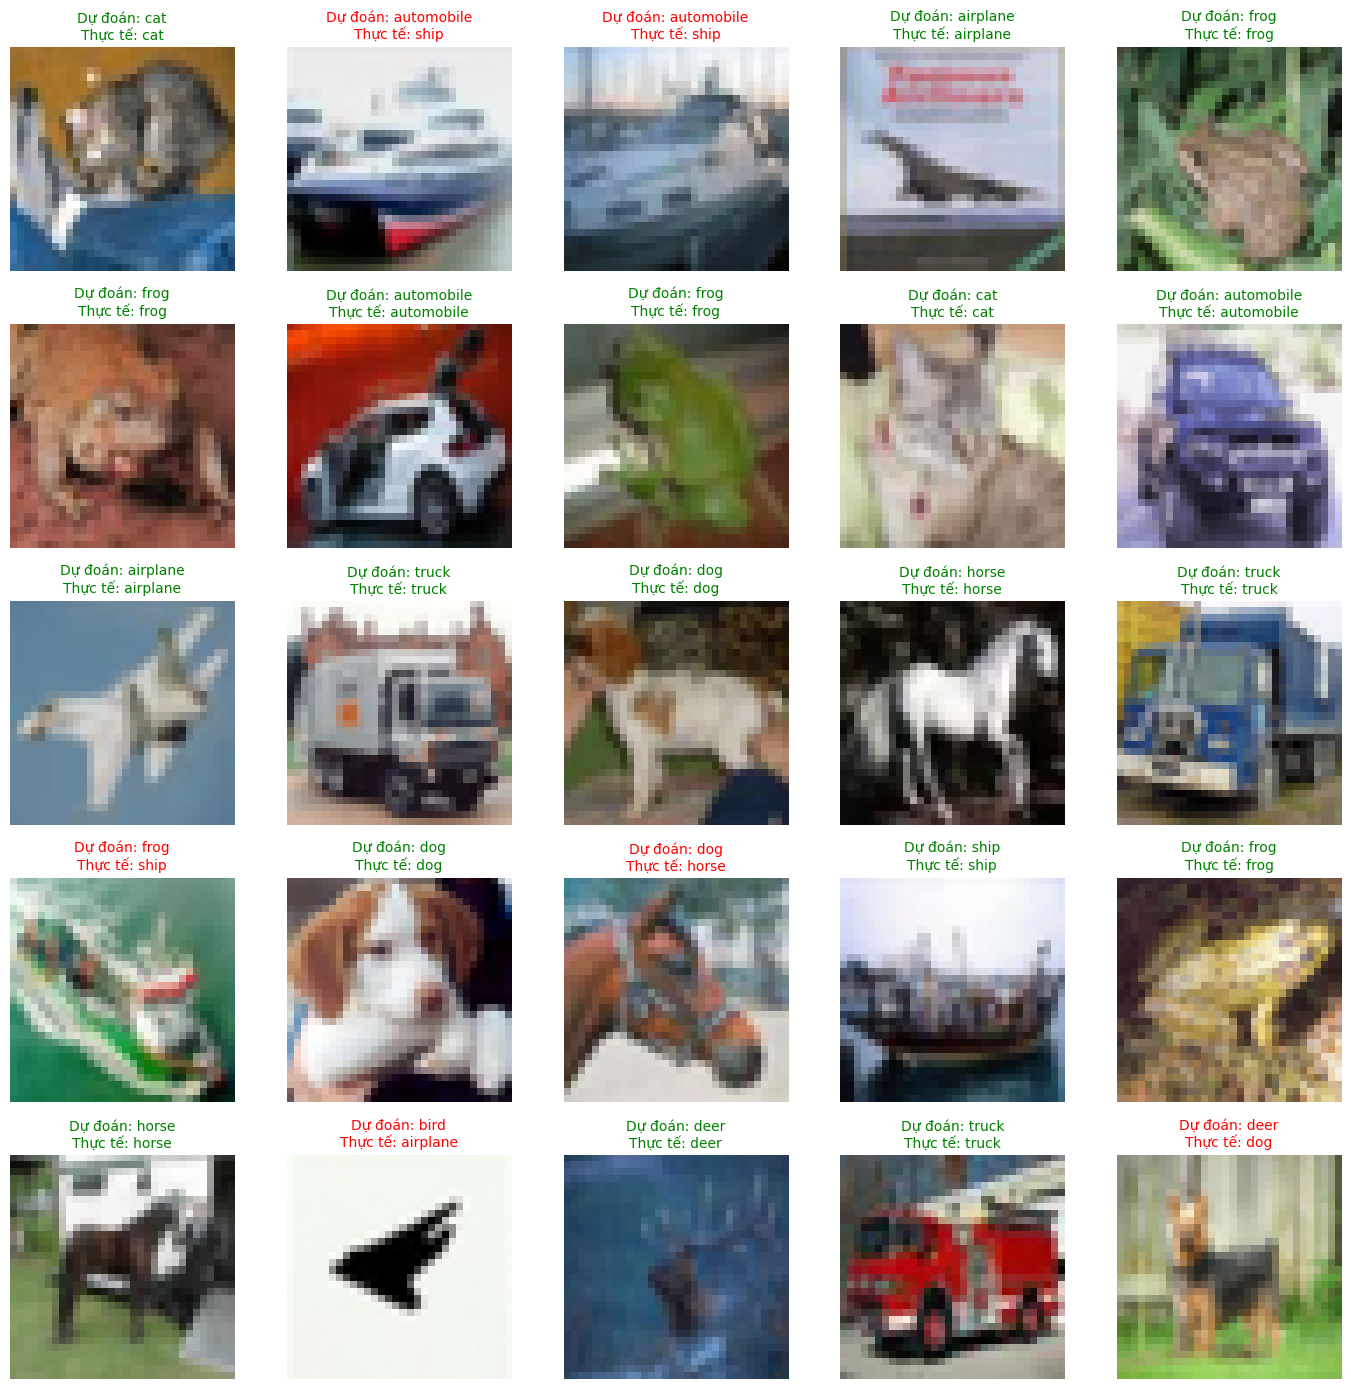

In [11]:
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (7, 7), activation='relu', padding='valid'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='valid'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(10, activation='softmax')
])

model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    batch_size=320,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

score = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]*100:.2f}%")

predictions = model.predict(X_test)

num_images = 25
plt.figure(figsize=(14, 14))

for i in range(num_images):
    plt.subplot(5, 5, i + 1)

    pred_idx = np.argmax(predictions[i])
    actual_idx = np.argmax(y_test[i])

    plt.imshow(X_test[i])

    title_color = 'green' if pred_idx == actual_idx else 'red'
    plt.title(f"Dự đoán: {class_names[pred_idx]}\nThực tế: {class_names[actual_idx]}", color=title_color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

2.  viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog.

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.A3BY1W_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Classes: ['Cat', 'Dog']


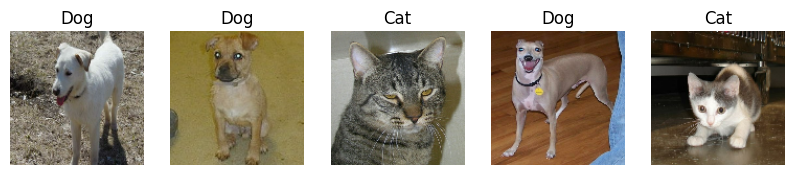

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 697s 1s/step - accuracy: 0.6496 - loss: 0.6167 - val_accuracy: 0.7388 - val_loss: 0.5187
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 630s 1s/step - accuracy: 0.7582 - loss: 0.4983 - val_accuracy: 0.7889 - val_loss: 0.4389
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 697s 1s/step - accuracy: 0.8126 - loss: 0.4130 - val_accuracy: 0.8121 - val_loss: 0.4114
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - accuracy: 0.8437 - loss: 0.3539 - val_accuracy: 0.8175 - val_loss: 0.4019
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 661s 1s/step - accuracy: 0.8728 - loss: 0.2986 - val_accuracy: 0.8403 - val_loss: 0.3702
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 678s 1s/step - accuracy: 0.8966 - loss: 0.2480 - val_accuracy: 0.8519 - val_loss: 0.3655
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 693s 1s/step - accuracy: 0.9161 - loss: 0.2001 - val_accuracy: 0.8512 - val_loss: 0.4021
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 666s 1s/step - accuracy: 0.9348 - loss: 0.1579 - val_accu

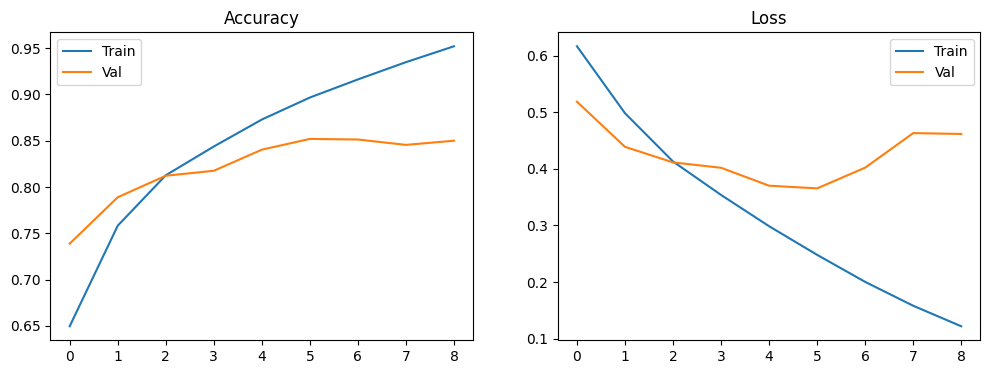

146/146 ━━━━━━━━━━━━━━━━━━━━ 44s 302ms/step - accuracy: 0.8519 - loss: 0.3655
Test Accuracy: 0.8518916368484497
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Dự đoán: Dog | Thực tế: Dog


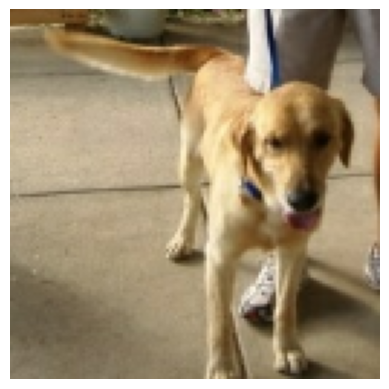

Đã lưu trọng số mô hình!


In [3]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 2. Tự động lấy dữ liệu (không cần folder bên ngoài)
(ds_train, ds_test), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

# 3. Tiền xử lý dữ liệu
def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(preprocess).cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).cache().batch(32).prefetch(tf.data.AUTOTUNE)

class_names = ["Cat", "Dog"]
print("Classes:", class_names)

# 4. Trực quan hóa dữ liệu
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 3))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.show()

# 5. Xây dựng CNN
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

# 6. Biên dịch mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Huấn luyện với EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(train_ds, validation_data=test_ds, epochs=10, callbacks=[es])

# 8. Vẽ đồ thị Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend(); plt.show()

# 9. Đánh giá
score = model.evaluate(test_ds)
print("Test Accuracy:", score[1])

# 10. Dự đoán thử nghiệm
for images, labels in test_ds.take(1):
    pred = model.predict(images[:1])
    predicted = "Dog" if pred[0][0] > 0.5 else "Cat"
    print("Dự đoán:", predicted, "| Thực tế:", class_names[int(labels[0])])
    plt.imshow(images[0])
    plt.axis("off"); plt.show()

# 11. Lưu mô hình
model.save_weights("catdog_final.weights.h5")
print("Đã lưu trọng số mô hình!")

3. viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


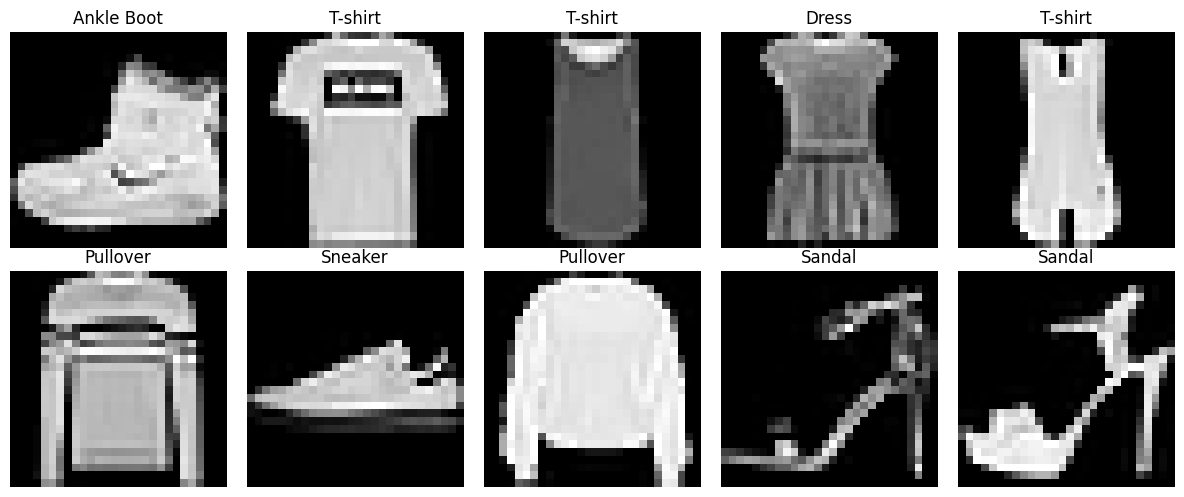

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 113ms/step - accuracy: 0.7491 - loss: 0.6896 - val_accuracy: 0.8452 - val_loss: 0.4221
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 110ms/step - accuracy: 0.8440 - loss: 0.4420 - val_accuracy: 0.8732 - val_loss: 0.3496
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - accuracy: 0.8634 - loss: 0.3811 - val_accuracy: 0.8765 - val_loss: 0.3190
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.8766 - loss: 0.3450 - val_accuracy: 0.8903 - val_loss: 0.2981
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.8858 - loss: 0.3188 - val_accuracy: 0.8957 - val_loss: 0.2753
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 112ms/step - accuracy: 0.8924 - loss: 0.3008 - val_accuracy: 0.9012 - val_loss: 0.2678
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - accuracy: 0.8968 - loss: 0.2822 - val_accuracy: 0.9072 - val_loss: 0.2532
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.9021 - loss: 0

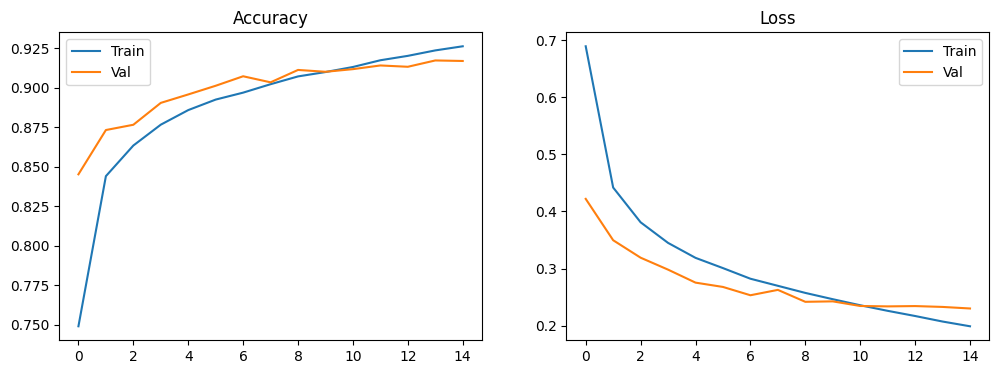

313/313 - 3s - 9ms/step - accuracy: 0.9130 - loss: 0.2469


Test Accuracy: 91.30%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


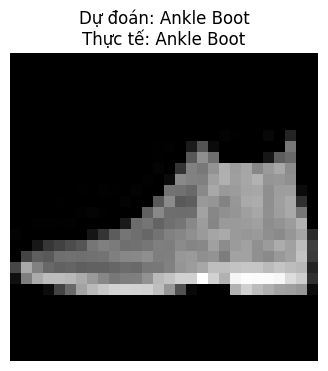

Đã lưu trọng số mô hình đã tối ưu!


In [4]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 2. Đọc dữ liệu Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
num_classes = 10
input_shape = (28, 28, 1)
fashion_labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

# 3. Chuẩn hóa và Reshape dữ liệu
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 4. Trực quan hóa dữ liệu mẫu
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(fashion_labels[y_train[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# 5. One-Hot Encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# 6. Xây dựng mô hình CNN
model = Sequential([
    Input(shape=input_shape),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Chống overfitting
    Dense(num_classes, activation='softmax')
])
model.summary()

# 7. Huấn luyện với EarlyStopping
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train, batch_size=128, epochs=15,
                    validation_split=0.1, callbacks=[es], verbose=1)

# 8. Đồ thị Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend(); plt.show()

# 9. Đánh giá trên tập Test
score = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {score[1]*100:.2f}%")

# 10. Dự đoán mẫu và hiển thị ảnh
plt.figure(figsize=(4, 4))
predict = model.predict(X_test[:1])
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Dự đoán: {fashion_labels[np.argmax(predict)]}\nThực tế: {fashion_labels[np.argmax(y_test[0])]}")
plt.axis('off')
plt.show()

# 11. Lưu trọng số mô hình
model.save_weights("fashion_cnn_optimized.weights.h5")
print("Đã lưu trọng số mô hình đã tối ưu!")

4. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh khuôn mặt {Nam, Nữ}.

### Giải quyết lỗi `FileNotFoundError`:

Lỗi `FileNotFoundError` xảy ra vì thư mục 'Gender/Train' hoặc 'Gender/Test' không tồn tại trong môi trường hiện tại của Colab.

Để khắc phục, bạn có hai lựa chọn:
1.  **Tải trực tiếp thư mục `Gender` lên Colab:** Kéo và thả thư mục `Gender` vào panel `Files` bên trái trong Colab. Tuy nhiên, các tệp này sẽ bị xóa khi phiên làm việc kết thúc.
2.  **Gắn kết Google Drive:** Đây là cách được khuyến khích để truy cập dữ liệu một cách bền vững. Bạn cần đảm bảo thư mục `Gender` được đặt trong Google Drive của bạn.

Tôi sẽ cung cấp mã để gắn kết Google Drive và sau đó sửa đổi đường dẫn trong mã để trỏ đến thư mục 'Gender' trong Google Drive của bạn. Vui lòng đảm bảo cấu trúc thư mục của bạn trong Google Drive giống như sau:

`My Drive/Gender/Train/...`
`My Drive/Gender/Test/...`

### Hướng dẫn tải tệp `Gender` thủ công lên Colab

Nếu bạn không muốn gắn kết Google Drive hoặc gặp lỗi khi gắn kết, bạn có thể tải thư mục `Gender` trực tiếp lên môi trường Colab. Lưu ý rằng các tệp này sẽ bị xóa khi phiên làm việc kết thúc.

**Các bước thực hiện:**

1.  **Chuẩn bị thư mục `Gender`:**
    *   Đảm bảo bạn có thư mục `Gender` trên máy tính của mình. Bên trong `Gender`, phải có hai thư mục con là `Train` và `Test`, và trong mỗi thư mục con này chứa các thư mục con khác tương ứng với các lớp (ví dụ: `Male`, `Female`) cùng với các tệp ảnh.
    *   Để dễ dàng tải lên, hãy nén thư mục `Gender` thành tệp `.zip` (ví dụ: `Gender.zip`).

2.  **Mở panel `Files` trong Colab:**
    *   Ở bên trái màn hình Colab, tìm biểu tượng thư mục (thường là biểu tượng `Files`). Nhấp vào đó để mở panel Files.

3.  **Tải tệp `.zip` lên:**
    *   Trong panel `Files`, tìm biểu tượng `Upload to session storage` (thường là một mũi tên chỉ lên trên). Nhấp vào đó.
    *   Một cửa sổ duyệt tệp sẽ hiện ra. Điều hướng đến vị trí của tệp `Gender.zip` trên máy tính của bạn và chọn nó để tải lên.
    *   Đợi quá trình tải lên hoàn tất. Bạn sẽ thấy tệp `Gender.zip` xuất hiện trong panel `Files`.

4.  **Giải nén tệp:**
    *   Sau khi tải lên, bạn cần giải nén tệp `Gender.zip`. Sử dụng mã sau trong một ô code mới và chạy nó:


In [15]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input
import matplotlib.pyplot as plt

# =====================================================================
# 2. Đọc dữ liệu từ thư mục (Hãy đảm bảo đường dẫn này tồn tại)
# =====================================================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Gender/Train", image_size=(128, 128), batch_size=32, shuffle=True
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Gender/Test", image_size=(128, 128), batch_size=32, shuffle=False
)
class_names = train_ds.class_names
print("Classes:", class_names)

# 3. Chuẩn hóa và tối ưu pipeline
norm = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# 4. Trực quan hóa dữ liệu mẫu
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 3))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.show()

# 5. Xây dựng kiến trúc CNN (Căn chỉnh chuẩn theo log cũ)
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (7, 7), activation='relu', padding='valid'),  # Kích thước ra: (None, 122, 122, 32)
    MaxPool2D((2, 2)),                                       # Kích thước ra: (None, 61, 61, 32)
    Conv2D(64, (3, 3), activation='relu', padding='valid'),  # Kích thước ra: (None, 59, 59, 64)
    MaxPool2D((2, 2)),                                       # Kích thước ra: (None, 29, 29, 64)
    Flatten(),                                               # Kích thước ra: (None, 53824)
    Dense(1, activation='sigmoid')                           # Kết nối thẳng ra lớp phân loại nhị phân
])

# Hiển thị cấu trúc mô hình để kiểm tra tham số (Params)
model.summary()

# 6. Biên dịch mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Huấn luyện cố định số Epochs (Đã bỏ EarlyStopping)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    verbose=1
)

# 8. Đồ thị đánh giá
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend(); plt.show()

# 9. Đánh giá mô hình
score = model.evaluate(test_ds, verbose=2)
print(f"Test Loss: {score[0]}")
print(f"Test Accuracy: {score[1]*100:.2f}%")

# =====================================================================
# 10. DỰ ĐOÁN VÀ HIỂN THỊ TẤT CẢ/NHIỀU ẢNH TRÊN TẬP TEST
# =====================================================================
# Lấy ra 1 batch (32 ảnh) từ tập test để hiển thị hàng loạt
for images, labels in test_ds.take(1):
    # Dự đoán cho toàn bộ batch này
    predictions = model.predict(images)

    plt.figure(figsize=(15, 15)) # Đặt kích thước khung lớn để chứa nhiều ảnh
    num_images = min(len(images), 25) # Hiển thị tối đa 25 ảnh đầu tiên từ batch

    for i in range(num_images):
        plt.subplot(5, 5, i + 1) # Lưới 5x5

        # Vì đầu ra sigmoid trả về xác suất từ 0 đến 1, lớn hơn 0.5 là class_names[1]
        raw_prob = predictions[i][0]
        predicted_idx = 1 if raw_prob > 0.5 else 0
        actual_idx = labels[i].numpy()

        predicted_label = class_names[predicted_idx]
        actual_label = class_names[actual_idx]

        plt.imshow(images[i].numpy())

        # Đổi chữ màu xanh nếu đoán đúng, màu đỏ nếu đoán sai
        title_color = 'green' if predicted_idx == actual_idx else 'red'

        # Hiển thị nhãn kèm xác suất thô (Raw value) cho giống phong cách log cũ của bạn
        plt.title(f"P: {predicted_label} ({raw_prob:.2f})\nT: {actual_label}", color=title_color, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    break # Dừng lại sau khi vẽ xong batch đầu tiên

# 11. Lưu trọng số mô hình
model.save_weights("gender_cnn_optimized.weights.h5")
print("Đã lưu trọng số mô hình mới!")

FileNotFoundError: [Errno 2] No such file or directory: 'Gender/Train'